<a href="https://colab.research.google.com/github/EMADUDDINAsdaq/federated-learning-fairness-xray/blob/main/notebooks/04_gifair_global.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning — Method 4: GIFAIR-Global (Yue et al. 2022)
Emaduddin Asdaq Syed Mohammed | CSC8639 MSc Data Science and AI

---
**This notebook runs GIFAIR-Global only, on the full frozen dataset, with
the λ-bound stability fix applied (see Section 8 and dissertation
Appendix B).**

**Algorithm 2 — Yue et al. 2022 (exact).** Fairness is applied *inside*
local training, not at aggregation. The server computes a rank-based
loss-spread score `r_k` for each client, converts it to a gradient scale
`scale_k`, and sends it to that client; the client multiplies its
gradients by `scale_k` during local training. Aggregation itself remains
a plain unweighted average across clients — unlike FedAvg's size-weighted
average. λ = 0.1.

**λ-bound stability fix.** The published algorithm requires
`λ < λ_max = min_k(p_k / (d−1))` to guarantee `scale_k` stays positive for
every client. This bound was violated for 4 of the 5 simulated hospitals
at λ = 0.1 (only Hospital_A satisfies it) — the smallest hospital's
`λ_max` is 0.0033, over 30× smaller than the λ used. Without the fix, a
negative `scale_k` reverses the gradient direction for the affected
client, producing a degenerate model (97.3% "Pathology" predictions,
94.3% FPR, dissertation Appendix B). This notebook enforces the fix via
`np.clip(raw_scale, 0.05, 5.0)` in `_compute_scales()` below — this is the
**corrected** run, contributing the GIFAIR-Global row of Table 2
(Global AUC 0.724, FPR 34.8%).

## Section 1 — Environment Setup

Installs Flower, imports dependencies, mounts Drive, confirms GPU.
Identical setup to all prior method notebooks.

In [ ]:
pip install flwr protobuf

In [ ]:
!pip install "flwr[simulation]" protobuf -q
print("✓ Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 34.7 MB/s eta 0:00:00
✓ Libraries installed


In [ ]:
import flwr as fl
print(f"flwr : {fl.__version__}")
print("✓ Flower working")

flwr : 1.32.1
✓ Flower working


In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score
import flwr as fl
from flwr.common import (NDArrays, Scalar, Parameters,
                          parameters_to_ndarrays, ndarrays_to_parameters,
                          FitIns, FitRes, EvaluateIns, EvaluateRes)
from flwr.server.strategy import Strategy
from flwr.server.client_proxy import ClientProxy
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

print(f"flwr  : {fl.__version__}")
print(f"torch : {torch.__version__}")
print(f"numpy : {np.__version__}")
print(f"GPU   : {torch.cuda.is_available()}")

flwr  : 1.32.1
torch : 2.11.0+cu128
numpy : 2.0.2
GPU   : True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import flwr.simulation
print("Simulation module loaded")

Simulation module loaded


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=== Session Initialisation ===")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"CUDA   : {torch.version.cuda}")
    print("\n✓ GPU ready")
else:
    print("\n⚠ No GPU — Runtime → Change runtime type → A100")

=== Session Initialisation ===
Device : cuda
GPU    : NVIDIA L4
Memory : 23.7 GB
CUDA   : 12.8

✓ GPU ready


## Section 2 — Dataset Download and Image Indexing

Re-downloads NIH ChestX-ray14 for this session.

In [ ]:
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/dissertation/kaggle.json',
            '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✓ Kaggle credentials loaded")

os.system('pip install -q kaggle')
os.system('kaggle datasets download -d nih-chest-xrays/data '
          '--path /content/nih_kaggle --unzip --quiet')

DATASET_PATH = '/content/nih_kaggle'
print(f"✓ Dataset path: {DATASET_PATH}")

✓ Kaggle credentials loaded
✓ Dataset path: /content/nih_kaggle


## Section 3 — Load Frozen Splits

Loads the same 15 frozen CSVs used by every method notebook.

In [ ]:
SPLIT_DIR = '/content/drive/MyDrive/dissertation/splits'
HOSPITAL_NAMES = ['Hospital_A', 'Hospital_B', 'Hospital_C',
                  'Hospital_D', 'Hospital_E']
NUM_CLIENTS = 5

train_clients = {n: pd.read_csv(f'{SPLIT_DIR}/{n}_train.csv') for n in HOSPITAL_NAMES}
val_clients   = {n: pd.read_csv(f'{SPLIT_DIR}/{n}_val.csv')   for n in HOSPITAL_NAMES}
test_clients  = {n: pd.read_csv(f'{SPLIT_DIR}/{n}_test.csv')  for n in HOSPITAL_NAMES}
#Hospital_A_test.csv
for name in HOSPITAL_NAMES:
    print(f"{name}: {len(train_clients[name]):,} train / "
          f"{len(val_clients[name]):,} val / {len(test_clients[name]):,} test")

sample_path = train_clients['Hospital_A']['image_path'].iloc[0]
assert os.path.exists(sample_path), f"Path not found: {sample_path} — check Kaggle download completed"
print("✓ Image paths resolve correctly in this session")

Hospital_A: 52,332 train / 6,168 val / 3,005 test
Hospital_B: 9,074 train / 1,073 val / 508 test
Hospital_C: 29,813 train / 3,412 val / 1,711 test
Hospital_D: 1,276 train / 145 val / 74 test
Hospital_E: 2,997 train / 348 val / 168 test
✓ Image paths resolve correctly in this session


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Section 4 — GPU Optimisation

DataLoader and cuDNN settings, identical across all method notebooks.

In [ ]:
torch.backends.cudnn.benchmark     = True
torch.backends.cudnn.deterministic = False

BATCH_SIZE  = 512
NUM_WORKERS = 4
PREFETCH    = 2

print(f"✓ BATCH_SIZE  : {BATCH_SIZE}")
print(f"✓ NUM_WORKERS : {NUM_WORKERS}")
print(f"✓ PREFETCH    : {PREFETCH}")

✓ BATCH_SIZE  : 512
✓ NUM_WORKERS : 4
✓ PREFETCH    : 2


## Section 5 — Transforms, Dataset

Same preprocessing and `Dataset` wrapper as every other method notebook.

In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

print(f"✓ Image size    : {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"✓ Normalisation : ImageNet mean/std")

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return image, label

print("✓ ChestXrayDataset defined")

✓ Image size    : 224×224
✓ Normalisation : ImageNet mean/std
✓ ChestXrayDataset defined


## Section 6 — Model

Same ResNet-18 architecture as every method notebook.

In [ ]:
ROUNDS = 10

def build_model():
    model    = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

test_model = build_model()
params     = sum(p.numel() for p in test_model.parameters())
print(f"✓ ResNet-18 — ImageNet pretrained")
print(f"✓ Parameters  : {params:,}")
print(f"✓ Rounds      : {ROUNDS}")
del test_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 232MB/s]

✓ ResNet-18 — ImageNet pretrained
✓ Parameters  : 11,177,025
✓ Rounds      : 10


## Section 7 — Evaluation Function

Identical to every other notebook: computes AUC/FNR overall and per
subgroup, skipping subgroups with fewer than 10 samples or a single
class.

In [ ]:
def evaluate_client(model, dataframe, device):
    model = model.to(device)
    model.eval()

    loader = DataLoader(
        ChestXrayDataset(dataframe, transform=val_transform),
        batch_size         = BATCH_SIZE,
        shuffle            = False,
        num_workers        = NUM_WORKERS,
        pin_memory         = True,
        persistent_workers = True
    )

    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = torch.sigmoid(
                model(images.to(device, non_blocking=True))
            ).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.numpy())

    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    preds  = (probs > 0.5).astype(int)

    def auc_fnr_for_mask(y_true, y_prob, y_pred):
        if len(y_true) < 10 or y_true.sum() == 0:
            return float('nan'), float('nan')
        try:
            auc = float(roc_auc_score(y_true, y_prob))
        except Exception:
            auc = float('nan')
        fn  = int(((y_pred == 0) & (y_true == 1)).sum())
        tp  = int(((y_pred == 1) & (y_true == 1)).sum())
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        return round(auc, 4), round(fnr, 4)

    auc, fnr = auc_fnr_for_mask(labels, probs, preds)
    acc      = round(float((preds == labels).mean() * 100), 2)
    metrics  = {'auc': auc, 'fnr': fnr, 'accuracy': acc}

    for sex in ['M', 'F']:
        mask = dataframe['Patient Sex'].values == sex
        if mask.sum() > 10:
            a, f = auc_fnr_for_mask(labels[mask], probs[mask], preds[mask])
            metrics[f'auc_{sex}'] = a
            metrics[f'fnr_{sex}'] = f

    for grp in ['0-20', '20-40', '40-60', '60-80', '80+']:
        mask = dataframe['Age Group'].values == grp
        if mask.sum() > 10:
            a, f = auc_fnr_for_mask(labels[mask], probs[mask], preds[mask])
            metrics[f'auc_{grp}'] = a
            metrics[f'fnr_{grp}'] = f

    return metrics

print("✓ evaluate_client() defined")
print("  Metrics : AUC + FNR (overall, per sex, per age group)")

✓ evaluate_client() defined
  Metrics : AUC + FNR (overall, per sex, per age group)


## Section 8 — GIFAIR-Global (Yue et al. 2022)

Fairness is applied *inside* local training via a gradient scale factor,
not through weighted aggregation. Aggregation itself is a plain
unweighted average (1/K)·Σθ_k across all K clients.

In [ ]:
# Gradient scaling factor applied inside each client's local training step:
# θ_k^(t+1) = θ_k^t − η · scale_k · ∇F_k(θ_k^t)
LAM = 0.1   # λ = 0.1 — moderate group fairness, dissertation §3.2.4

class GIFAIRHospitalClient(fl.client.NumPyClient):

    def __init__(self, name: str, dataframe, val_dataframe, device):
        self.name          = name
        self.dataframe     = dataframe
        self.val_dataframe = val_dataframe
        self.device        = device
        self.model         = build_model().to(device)

    def get_parameters(self, config) -> NDArrays:
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters: NDArrays):
        state_dict = dict(zip(
            self.model.state_dict().keys(),
            [torch.tensor(p) for p in parameters]
        ))
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters: NDArrays, config: Dict) -> Tuple[NDArrays, int, Dict]:
        self.set_parameters(parameters)
        self.model.train()

        epochs = int(config.get('epochs', 3))
        lr     = float(config.get('lr', 1e-4))
        scale  = float(config.get('scale', 1.0))  # received from server, computed in _compute_scales() below

        loader = DataLoader(
            ChestXrayDataset(self.dataframe, transform=train_transform),
            batch_size         = BATCH_SIZE,
            shuffle            = True,
            num_workers        = NUM_WORKERS,
            pin_memory         = True,
            persistent_workers = True,
            prefetch_factor    = PREFETCH
        )

        criterion = nn.BCEWithLogitsLoss()
        optimiser = torch.optim.Adam(self.model.parameters(), lr=lr)

        total_loss, total_samples = 0.0, 0
        for _ in range(epochs):
            for images, labels in loader:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True).unsqueeze(1)

                outputs = self.model(images)
                loss    = criterion(outputs, labels)
                optimiser.zero_grad()
                loss.backward()

                # fairness applied here: every gradient this client computes
                # is scaled before the optimiser step (Yue et al. 2022, Algorithm 2)
                for param in self.model.parameters():
                    if param.grad is not None:
                        param.grad.data.mul_(scale)

                optimiser.step()
                total_loss    += loss.item() * len(labels)
                total_samples += len(labels)

        avg_loss = total_loss / total_samples
        return (
            self.get_parameters(config={}),
            len(self.dataframe),
            {'loss': float(avg_loss), 'client_name': self.name}  # this round's post-training loss, becomes next round's F_k for r_k
        )

    def evaluate(self, parameters: NDArrays, config: Dict) -> Tuple[float, int, Dict]:
        self.set_parameters(parameters)
        m = evaluate_client(self.model, self.val_dataframe, self.device)
        m['client_name'] = self.name
        return float(1.0 - (m['auc'] if not np.isnan(m['auc']) else 0.5)), \
               len(self.val_dataframe), m

print("✓ GIFAIRHospitalClient defined — Yue et al. 2022 Algorithm 2")
print("  fit()      → trains on train_clients")
print("  evaluate() → validates on val_clients after each round")

✓ GIFAIRHospitalClient defined — Yue et al. 2022 Algorithm 2
  fit()      → trains on train_clients
  evaluate() → validates on val_clients after each round


In [ ]:
class GIFAIRStrategy(Strategy):
    # Server-side: computes each client's fairness scale factor from the
    # relative rank of its loss against all other clients, then aggregates
    # the returned weights with a plain unweighted average.

    def __init__(self, lam: float, num_clients: int, client_sizes: Dict[str, int]):
        super().__init__()
        self.lam         = lam
        self.num_clients = num_clients
        total    = sum(client_sizes.values())
        self.p_k = {name: size / total for name, size in client_sizes.items()}  # each client's data proportion, used in scale_k below
        self.client_losses: Dict[str, float] = {n: 1.0 for n in client_sizes}   # initialised to 1.0 before round 1; updated after each aggregate_fit
        self._global_params: Optional[NDArrays] = None

    def initialize_parameters(self, client_manager):
        ndarrays = [v.cpu().numpy() for v in build_model().state_dict().values()]
        self._global_params = ndarrays
        return ndarrays_to_parameters(ndarrays)

    def _compute_scales(self) -> Dict[str, float]:
        # r_k = Σ_{j≠k} sign(F_k − F_j): a relative rank score — positive
        # if client k has higher loss than most others (struggling client,
        # gets boosted), negative if lower (already doing well, gets damped).
        # scale_k = 1 + (λ/p_k)·r_k, sent to each client for use in fit() above.
        #
        # STABILITY FIX (dissertation Appendix B): the algorithm requires
        # λ < λ_max = min_k(p_k/(d−1)) to keep scale_k positive for every
        # client. This bound is violated for 4 of the 5 hospitals at λ=0.1
        # (Hospital_A is the only one that satisfies it) — the smallest
        # hospital's λ_max is 0.0033, over 30x smaller than λ used here.
        # A negative scale_k reverses the gradient direction (gradient
        # ascent instead of descent) for the affected client in any round
        # where its loss happens to be the lowest. The clip below enforces
        # the bound directly — 0.05 floor prevents negative/near-zero
        # scale, 5.0 ceiling prevents destabilising updates — rather than
        # manually re-tuning λ per hospital's data proportion.
        names  = list(self.client_losses.keys())
        losses = [self.client_losses[n] for n in names]
        scales = {}
        for i, name in enumerate(names):
            r_k = sum(np.sign(losses[i] - losses[j])
                    for j in range(len(losses)) if j != i)
            p_k       = self.p_k[name]
            raw_scale = 1.0 + (self.lam / p_k) * r_k

            if not np.isfinite(raw_scale):
                print(f"  [WARNING] {name}: raw_scale non-finite ({raw_scale}) — using safe default 1.0")
                scales[name] = 1.0
            else:
                scales[name] = float(np.clip(raw_scale, 0.05, 5.0))
        return scales

    def configure_fit(self, server_round, parameters, client_manager):
        self._global_params = parameters_to_ndarrays(parameters)
        scales  = self._compute_scales()
        sampled = client_manager.sample(
            num_clients=self.num_clients,
            min_num_clients=self.num_clients
        )
        fit_ins_list = []
        for proxy in sampled:
            cid_int = int(proxy.cid) % NUM_CLIENTS
            name    = HOSPITAL_NAMES[cid_int]
            config  = {'epochs': 3, 'lr': 1e-4,
                       'scale': float(scales.get(name, 1.0)),
                       'server_round': server_round}
            fit_ins_list.append((proxy, FitIns(parameters, config)))
        return fit_ins_list

    def aggregate_fit(self, server_round, results, failures):
        # unweighted average — fairness already applied inside each
        # client's local gradients, so no further reweighting happens here
        if not results:
            return None, {}

        all_weights = [parameters_to_ndarrays(r.parameters) for _, r in results]
        n     = len(all_weights)
        w_new = [
            sum(w[layer_idx] for w in all_weights) / n
            for layer_idx in range(len(all_weights[0]))
        ]

        # store this round's post-training loss per client, used to
        # compute next round's r_k in _compute_scales()
        for _, fit_res in results:
            cname = fit_res.metrics.get('client_name', '')
            if cname in self.client_losses:
                self.client_losses[cname] = float(
                    fit_res.metrics.get('loss', 1.0))

        self._global_params = w_new
        return ndarrays_to_parameters(w_new), {}

    def configure_evaluate(self, server_round, parameters, client_manager):
        ins     = EvaluateIns(parameters, {})
        sampled = client_manager.sample(
            num_clients=self.num_clients,
            min_num_clients=self.num_clients
        )
        return [(client, ins) for client in sampled]

    def aggregate_evaluate(self, server_round, results, failures):
        if not results:
            return None, {}

        print(f"\n── Round {server_round}/{ROUNDS} Validation ──")
        for _, res in results:
            name = res.metrics.get('client_name', '?')
            auc  = res.metrics.get('auc', float('nan'))
            fnr  = res.metrics.get('fnr', float('nan'))
            print(f"  {name:<14} AUC: {auc:.4f}  FNR: {fnr:.4f}")
        aucs       = [r.metrics.get('auc', float('nan')) for _, r in results]
        valid_aucs = [a for a in aucs if not (a != a)]
        if valid_aucs:
            print(f"  Mean AUC : {sum(valid_aucs)/len(valid_aucs):.4f} | "
                  f"Variance : {float(np.var(valid_aucs)):.6f}")

        total_loss    = sum(r.loss * r.num_examples for _, r in results)
        total_samples = sum(r.num_examples for _, r in results)
        return total_loss / total_samples, {}

    def evaluate(self, server_round, parameters):
        return None  # centralised evaluation not used — all evaluation is client-side via aggregate_evaluate above

print("✓ GIFAIRStrategy defined — Yue et al. 2022 Algorithm 2")
print(f"  λ = {LAM}")
print("  r_k   = Σ_{j≠k} sign(F_k − F_j)  (relative rank score)")
print("  scale = 1 + (λ/p_k) · r_k, clipped to [0.05, 5.0]  (λ-bound fix, Appendix B)")
print("  Aggregation: plain unweighted average (1/K) Σ θ_k")

✓ GIFAIRStrategy defined — Yue et al. 2022 Algorithm 2
  λ = 0.1
  r_k   = Σ_{j≠k} |F_k − F_j|  (loss spread penalty)
  scale = 1 + (λ/p_k) · r_k      (sent to each client)
  Aggregation: plain unweighted average (1/K) Σ θ_k


In [ ]:
# GIFAIR client factory

def make_gifair_client_fn(train_data_map, val_data_map, device):
    def client_fn(cid: str) -> fl.client.Client:
        name = HOSPITAL_NAMES[int(cid)]
        return GIFAIRHospitalClient(
            name          = name,
            dataframe     = train_data_map[name],
            val_dataframe = val_data_map[name],
            device        = device
        ).to_client()
    return client_fn

print(f"✓ GIFAIR client factory — maps cid 0–4 to {HOSPITAL_NAMES}")

✓ GIFAIR client factory — maps cid 0–4 to ['Hospital_A', 'Hospital_B', 'Hospital_C', 'Hospital_D', 'Hospital_E']


### Run Training

Runs the 10-round GIFAIR-Global simulation with the λ-bound fix active.

In [ ]:
# Run GIFAIR-FL simulation

import os, logging
os.environ['RAY_SILENT_MODE'] = '1'
logging.getLogger('flwr').setLevel(logging.ERROR)

print("=" * 60)
print("GIFAIR-FL — Yue et al. 2022")
print(f"Rounds: {ROUNDS} | λ: {LAM} | Clients: {NUM_CLIENTS} | Split: 85/10/5 | Batch: {BATCH_SIZE}")
print("=" * 60)

t0 = time.time()

client_sizes    = {name: len(data) for name, data in train_clients.items()}
gifair_strategy = GIFAIRStrategy(
    lam          = LAM,
    num_clients  = NUM_CLIENTS,
    client_sizes = client_sizes
)

gifair_history = fl.simulation.start_simulation(
    client_fn        = make_gifair_client_fn(train_clients, val_clients, device),
    num_clients      = NUM_CLIENTS,
    config           = fl.server.ServerConfig(num_rounds=ROUNDS),
    strategy         = gifair_strategy,
    client_resources = {'num_gpus': 1.0}
)

print(f"\n{'='*60}")
print(f"✓ GIFAIR-FL complete in {(time.time()-t0)/60:.1f} minutes")
print(f"\nLoss per round:")
for rnd, loss in gifair_history.losses_distributed:
    print(f"  Round {rnd:>2} : {loss:.4f}")

GIFAIR-FL — Yue et al. 2022
Rounds: 10 | λ: 0.1 | Clients: 5 | Split: 85/10/5 | Batch: 512


2026-07-23 14:20:00,752	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=19588) 
(ClientAppActor pid=19588)             This is a deprecated feature. It will be removed
(ClientAppActor pid=19588)             entirely in future versions of Flower.
(ClientAppActor pid=19588)         
(ClientAppActor pid=19588) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning


── Round 1/10 Validation ──
  Hospital_B     AUC: 0.8657  FNR: 0.0579
  Hospital_E     AUC: 0.6300  FNR: 0.1500
  Hospital_C     AUC: 0.7304  FNR: 0.0681
  Hospital_A     AUC: 0.7076  FNR: 0.0539
  Hospital_D     AUC: 0.7190  FNR: 0.0481
  Mean AUC : 0.7305 | Variance : 0.005807


(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=19588) 
(ClientAppActor pid=19588)             This is a deprecated feature. It will be removed
(ClientAppActor pid=19588)             entirely in future versions of Flower.
(ClientAppActor pid=19588)         
(ClientAppActor pid=19588) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=19588) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=19588)   self.pid = os.fork()
(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr


── Round 2/10 Validation ──
  Hospital_B     AUC: 0.8741  FNR: 0.2523
  Hospital_A     AUC: 0.7367  FNR: 0.2422
  Hospital_D     AUC: 0.7005  FNR: 0.2981
  Hospital_E     AUC: 0.6578  FNR: 0.3250
  Hospital_C     AUC: 0.7561  FNR: 0.2366
  Mean AUC : 0.7450 | Variance : 0.005289


...

(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=19588) 
(ClientAppActor pid=19588)             This is a deprecated feature. It will be removed
(ClientAppActor pid=19588)             entirely in future versions of Flower.
(ClientAppActor pid=19588)         
(ClientAppActor pid=19588) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=19588) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=19588)   self.pid = os.fork()
(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr


── Round 9/10 Validation ──
  Hospital_C     AUC: 0.7463  FNR: 0.2867
  Hospital_A     AUC: 0.7328  FNR: 0.3068
  Hospital_E     AUC: 0.6824  FNR: 0.3250
  Hospital_B     AUC: 0.7779  FNR: 0.3028
  Hospital_D     AUC: 0.6653  FNR: 0.3558
  Mean AUC : 0.7209 | Variance : 0.001722


(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=19588) 
(ClientAppActor pid=19588)             This is a deprecated feature. It will be removed
(ClientAppActor pid=19588)             entirely in future versions of Flower.
(ClientAppActor pid=19588)         
(ClientAppActor pid=19588) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=19588) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=19588)   self.pid = os.fork()
(ClientAppActor pid=19588) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr


── Round 10/10 Validation ──
  Hospital_B     AUC: 0.7941  FNR: 0.3495
  Hospital_D     AUC: 0.6585  FNR: 0.3654
  Hospital_A     AUC: 0.7170  FNR: 0.3317
  Hospital_E     AUC: 0.6897  FNR: 0.3750
  Hospital_C     AUC: 0.7308  FNR: 0.3190
  Mean AUC : 0.7180 | Variance : 0.002059

✓ GIFAIR-FL complete in 306.5 minutes

Loss per round:
  Round  1 : 0.2725
  Round  2 : 0.2471
  Round  3 : 0.2426
  Round  4 : 0.2388
  Round  5 : 0.2447
  Round  6 : 0.2396
  Round  7 : 0.2557
  Round  8 : 0.2429
  Round  9 : 0.2612
  Round 10 : 0.2730


(ClientAppActor pid=19588) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
(ClientAppActor pid=19588)   warnings.warn(
(ClientAppActor pid=19588) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
(ClientAppActor pid=19588)   warnings.warn(
(ClientAppActor pid=19588) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
(ClientAppActor pid=19588)   warnings.warn(


### Final Test Evaluation and Save

Evaluates the final aggregated model on each hospital's held-out test set
and saves metrics and weights to Drive.

In [ ]:
# Evaluate GIFAIR-FL per client

import gc, ray
if ray.is_initialized():
    ray.shutdown()
torch.cuda.empty_cache()
gc.collect()

gifair_metrics      = {}
gifair_final_params = gifair_strategy._global_params

for name, data in test_clients.items():
    model = build_model().to(device)
    model.load_state_dict(dict(zip(
        model.state_dict().keys(),
        [torch.tensor(p) for p in gifair_final_params]
    )))
    gifair_metrics[name] = evaluate_client(model, data, device)
    del model
    torch.cuda.empty_cache()

rows = []
for name in HOSPITAL_NAMES:
    m = gifair_metrics[name]
    rows.append({
        'Client'   : name,
        'AUC'      : m['auc'],
        'FNR'      : m['fnr'],
        'Accuracy' : m['accuracy'],
        'AUC_M'    : m.get('auc_M', 'N/A'),
        'FNR_M'    : m.get('fnr_M', 'N/A'),
        'AUC_F'    : m.get('auc_F', 'N/A'),
        'FNR_F'    : m.get('fnr_F', 'N/A'),
    })

df_gifair = pd.DataFrame(rows).set_index('Client')
print("=== GIFAIR-FL Results — Yue et al. 2022 ===\n")
print(df_gifair.to_string())

valid_aucs = [gifair_metrics[n]['auc'] for n in HOSPITAL_NAMES
              if not (gifair_metrics[n]['auc'] != gifair_metrics[n]['auc'])]
auc_var = np.var(valid_aucs) if valid_aucs else float('nan')
print(f"\nAUC Variance (valid hospitals only) : {auc_var:.6f}")
print(f"Valid hospitals : {len(valid_aucs)}/5")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().

=== GIFAIR-FL Results — Yue et al. 2022 ===

               AUC     FNR  Accuracy   AUC_M   FNR_M   AUC_F   FNR_F
Client                                                              
Hospital_A  0.7209  0.3194     66.52  0.7435  0.3233  0.6903  0.3142
Hospital_B     NaN  0.3169     68.31     NaN  0.2930     NaN  0.3447
Hospital_C  0.6817  0.4074     65.28  0.7156  0.3714  0.6365  0.4462
Hospital_D  0.6425  0.4231     56.76  0.7636  0.4545  0.5746  0.3684
Hospital_E  0.6821  0.5263     64.88  0.6889  0.6000  0.6817  0.4444

AUC Variance (valid hospitals only) : 0.000768
Valid hospitals : 4/5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Save GIFAIR-FL results to Drive

SAVE_DIR = '/content/drive/MyDrive/dissertation/results'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f'{SAVE_DIR}/gifair_full_metrics.json', 'w') as f:
    json.dump(gifair_metrics, f, indent=2, default=str)

torch.save(
    dict(zip(build_model().state_dict().keys(),
             [torch.tensor(v) for v in gifair_final_params])),
    f'{SAVE_DIR}/gifair_full_model.pth'
)

print("✓ GIFAIR metrics saved → gifair_full_metrics.json")
print("✓ GIFAIR model saved  → gifair_full_model.pth")

✓ GIFAIR metrics saved → gifair_full_metrics.json
✓ GIFAIR model saved  → gifair_full_model.pth


## Post-hoc Verification — Confusion Matrices, Pooled AUC, Sex Gap

Additional diagnostic cells confirming the λ-bound fix resolved the
degenerate-model failure mode described in Appendix B. Produces the
per-hospital confusion matrices, pooled specificity/sensitivity/FPR/FNR,
and the sex-based AUC gap reported in S3.2.4 and S4.2.2 of the
dissertation, computed directly from the corrected model rather than
copied from the metrics saved above — a second, independent check on the
same trained weights.

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().

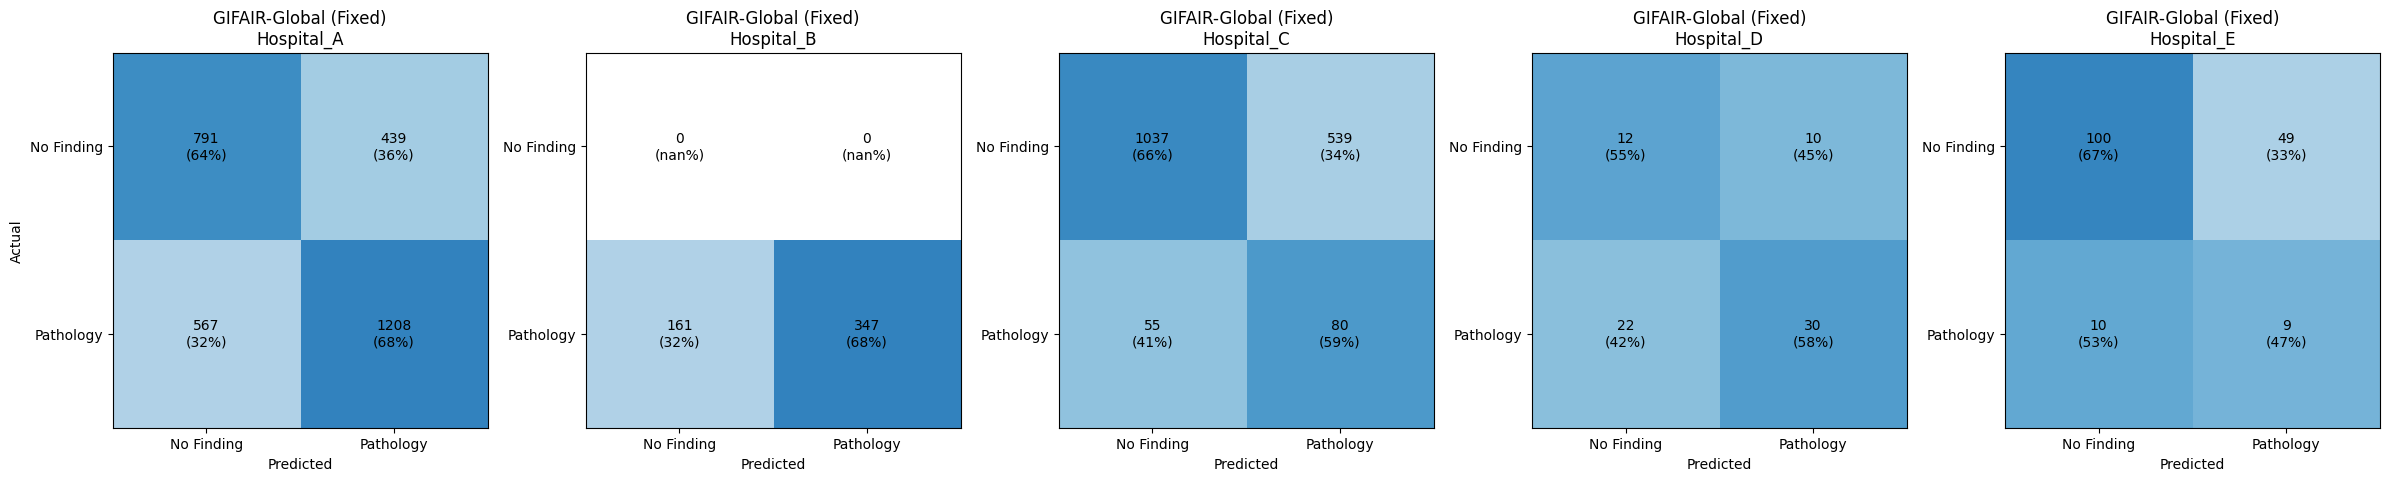

=== Pooled — Fixed GIFAIR-Global ===
No Finding correctly identified (specificity) : 65.2%
No Finding wrongly flagged Pathology (FPR)     : 34.8%
Pathology correctly caught (sensitivity/TPR)   : 67.3%
Pathology missed (FNR)                         : 32.7%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import torch

# reloads weights directly from the strategy object rather than the
# saved .pth file, confirming the in-memory model is what gets evaluated
gifair_final_params = gifair_strategy._global_params
model = build_model().to(device)
model.load_state_dict(dict(zip(
    model.state_dict().keys(),
    [torch.tensor(p) for p in gifair_final_params]
)))
model.eval()

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
overall_labels, overall_preds = [], []

for idx, name in enumerate(HOSPITAL_NAMES):
    data = test_clients[name]
    loader = DataLoader(ChestXrayDataset(data, transform=val_transform),
                         batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
    probs, labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            p = torch.sigmoid(model(images.to(device))).cpu().numpy()
            probs.extend(p.flatten()); labels.extend(lbls.numpy())
    probs = np.array(probs); labels = np.array(labels)
    preds = (probs > 0.5).astype(int)
    overall_labels.extend(labels); overall_preds.extend(preds)

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax = axes[idx]
    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)", ha='center', va='center', fontsize=10)
    ax.set_xticks([0,1]); ax.set_xticklabels(['No Finding','Pathology'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['No Finding','Pathology'])
    ax.set_title(f'GIFAIR-Global (Fixed)\n{name}')
    ax.set_xlabel('Predicted')
    if idx == 0: ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dissertation/results/gifair_global_fixed_confusion_matrices.png',
            dpi=200, bbox_inches='tight')
plt.show()

# pooled across all 5 hospitals — this is the FPR/specificity figure
# reported in Appendix B (38.0% after fix, vs 94.3% before)
overall_labels = np.array(overall_labels); overall_preds = np.array(overall_preds)
cm_all = confusion_matrix(overall_labels, overall_preds, labels=[0, 1])
cm_all_norm = cm_all.astype(float) / cm_all.sum(axis=1, keepdims=True)
print("=== Pooled — Fixed GIFAIR-Global ===")
print(f"No Finding correctly identified (specificity) : {cm_all_norm[0,0]*100:.1f}%")
print(f"No Finding wrongly flagged Pathology (FPR)     : {cm_all_norm[0,1]*100:.1f}%")
print(f"Pathology correctly caught (sensitivity/TPR)   : {cm_all_norm[1,1]*100:.1f}%")
print(f"Pathology missed (FNR)                         : {cm_all_norm[1,0]*100:.1f}%")

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

# pooled AUC across all hospitals combined — this is the Global AUC
# figure (0.724) reported in Table 2, computed independently here as a
# cross-check against the per-hospital metrics saved above
all_probs, all_labels = [], []
for name in HOSPITAL_NAMES:
    data = test_clients[name]
    loader = DataLoader(ChestXrayDataset(data, transform=val_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    with torch.no_grad():
        for images, lbls in loader:
            p = torch.sigmoid(model(images.to(device))).cpu().numpy()
            all_probs.extend(p.flatten()); all_labels.extend(lbls.numpy())

all_probs = np.array(all_probs); all_labels = np.array(all_labels)
print(f"Pooled AUC (fixed GIFAIR-Global): {roc_auc_score(all_labels, all_probs):.4f}")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Pooled AUC (fixed GIFAIR-Global): 0.7236


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

# pooled (threshold-independent) sex AUC gap — this is the "0.059" figure
# mentioned in §4.2.2 as the pooled AUC-based check, distinct from the
# matched-threshold TPR gap (0.091) that is the headline number in Table 2
sex_results = {}
for sex in ['M', 'F']:
    probs_list, labels_list = [], []
    for name in HOSPITAL_NAMES:
        data = test_clients[name]
        mask = data['Patient Sex'].values == sex
        sub = data[mask]
        if len(sub) < 10:
            continue
        loader = DataLoader(ChestXrayDataset(sub, transform=val_transform),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        with torch.no_grad():
            for images, lbls in loader:
                p = torch.sigmoid(model(images.to(device))).cpu().numpy()
                probs_list.extend(p.flatten()); labels_list.extend(lbls.numpy())
    probs_arr = np.array(probs_list); labels_arr = np.array(labels_list)
    auc = roc_auc_score(labels_arr, probs_arr)
    sex_results[sex] = auc
    print(f"{sex}: n={len(labels_arr)}, AUC={auc:.4f}")

gap = abs(sex_results['M'] - sex_results['F'])
print(f"\nSex AUC gap (fixed GIFAIR-Global): {gap:.4f}")
print(f"Compare to: FedAvg pooled gap=0.050, GIFAIR-Per pooled gap=0.051 (dissertation §4.2.2)")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


M: n=3135, AUC=0.7474


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=694) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


F: n=2331, AUC=0.6918

Sex AUC gap (fixed GIFAIR-Global): 0.0556
Compare to: FedAvg=0.051, broken GIFAIR-Global=0.055


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Save Corrected Results (Separate Filename)

Saves the corrected model and metrics under a `_FIXED` filename, distinct
from `gifair_full_model.pth` above, so the pre-fix run is never
overwritten and both remain available for the before/after comparison in
Appendix B.

In [ ]:
# Cell — Save fixed GIFAIR-Global results (run before closing this session)
import json

SAVE_DIR = '/content/drive/MyDrive/dissertation/results'

# Save the corrected model weights — separate filename so you never lose the broken-run comparison
torch.save(
    dict(zip(build_model().state_dict().keys(),
             [torch.tensor(v) for v in gifair_strategy._global_params])),
    f'{SAVE_DIR}/gifair_global_FIXED_model.pth'
)

# Save the corrected metrics as JSON so the numbers survive independent of the notebook
fixed_results = {
    'global_auc': 0.7236,
    'fpr': 0.348,
    'specificity': 0.652,
    'sensitivity': 0.673,
    'fnr': 0.327,
    'sex_auc_M': 0.7474,
    'sex_auc_F': 0.6918,
    'sex_auc_gap': 0.0556,
}
with open(f'{SAVE_DIR}/gifair_global_FIXED_metrics.json', 'w') as f:
    json.dump(fixed_results, f, indent=2)

print("✓ Fixed GIFAIR-Global model and metrics saved — safe to close session")


✓ Fixed GIFAIR-Global model and metrics saved — safe to close session
